# Step1: Installation and Setup

In [1]:
# Install library for older video formats (MPEG2)
!apt-get install -y libavcodec-extra -qq

# Install YOLOv8 and OpenCV for video/image processing
!pip install ultralytics opencv-python-headless -q

Selecting previously unselected package libaribb24-0:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libaribb24-0_1.0.3-2_amd64.deb ...
Unpacking libaribb24-0:amd64 (1.0.3-2) ...
Selecting previously unselected package libopencore-amrnb0:amd64.
Preparing to unpack .../libopencore-amrnb0_0.1.5-1_amd64.deb ...
Unpacking libopencore-amrnb0:amd64 (0.1.5-1) ...
Selecting previously unselected package libopencore-amrwb0:amd64.
Preparing to unpack .../libopencore-amrwb0_0.1.5-1_amd64.deb ...
Unpacking libopencore-amrwb0:amd64 (0.1.5-1) ...
Selecting previously unselected package libvo-amrwbenc0:amd64.
Preparing to unpack .../libvo-amrwbenc0_0.1.3-2_amd64.deb ...
Unpacking libvo-amrwbenc0:amd64 (0.1.3-2) ...
dpkg: libavcodec58:amd64: dependency problems, but removing anyway as you requested:
 libchromaprint1:amd64 depends on libavcodec58 (>= 7:4.4).
 libavformat58:amd64 depends on libavcodec58 (= 7:4.4.2-0ubuntu0.22.04.1).
 libavfilter7:a

In [70]:
# Import Google Drive mounting library
from google.colab import drive

# Mount Drive to access stored videos
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2: Object Detection using YOLOv8

In [12]:
# Import YOLO model & libraries that handle video
from ultralytics import YOLO
import cv2
import os

# YOLO mini version (yolov8n) for faster performance.
model = YOLO('yolov8n.pt')

# path containing the videos
videos_path = "/content/drive/MyDrive/CV_Project/"

#  list of all the videos that end with mp4, mpg, avi
video_files = []
for f in os.listdir(videos_path):
    if f.endswith(('.mp4', '.mpg', '.avi')):
        video_files.append(f)

# Print Number of videos
print(f" Number of videos: {len(video_files)}")
print("-" * 50)

# Folder that saves images for the report
os.makedirs("screenshots", exist_ok=True)

# Loop passes over every video
for video_name in video_files:

    # Full path for each video
    video_path = os.path.join(videos_path, video_name)
    print(f"\n play : {video_name}")

    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Total frames counter processed
    frame_count = 0
    # Saved screenshots counter (max 3 per video)
    saved_images = 0

    # Read the full video frames
    while cap.isOpened():

        # Read one frame of the video
        ret, frame = cap.read()

        # Exit the loop once the video is finished
        if not ret:
            break

        #  Increase the frame counter
        frame_count += 1

        # Run the model to detect objects
        # persist=True it retains id num between frames (tracking)
        # Confidence threshold, 15% or more the object is considered detected
        results = model(frame, conf=0.15)

        # Calculate the num of objects detected within this frame
        if results[0].boxes is not None:
            num_objects = len(results[0].boxes)
        else:
            num_objects = 0

        # There are objects and we have saved < 3 images; save more images
        if num_objects > 0 and saved_images < 3:
            # Name the image with the video name + frame number
            safe_name = video_name.replace('.', '_')
            filename = f"screenshots/{safe_name}_frame{frame_count}.png"

            # Save the image with the squares drawn by the model
            cv2.imwrite(filename, results[0].plot())

            # Show which frame was saved and how many objects
            print(f" frame {frame_count}: {num_objects} object (saved)")
            saved_images += 1

    # Release the video capture object
    cap.release()

    # Print num of frames we're done with this video.
    print(f" Frames done: {frame_count} ")

print("\n" + "-" * 50)
print(f" images in 'screenshots'")

Streaming output truncated to the last 5000 lines.
Speed: 3.2ms preprocess, 10.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 persons, 1 handbag, 13 chairs, 3 dining tables, 8.0ms
Speed: 3.5ms preprocess, 8.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 1 handbag, 14 chairs, 2 dining tables, 7.7ms
Speed: 3.1ms preprocess, 7.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 1 handbag, 13 chairs, 1 dining table, 9.1ms
Speed: 3.1ms preprocess, 9.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 1 handbag, 12 chairs, 1 dining table, 1 laptop, 8.7ms
Speed: 2.5ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 person, 1 handbag, 13 chairs, 1 dining table, 1 laptop, 8.6ms
Speed: 2.9ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 perso

In [7]:
# Compress folder (screenshots5)
!zip -r screenshots.zip screenshots/

# Download the file
from google.colab import files
files.download("screenshots.zip")

  adding: screenshots/ (stored 0%)
  adding: screenshots/LeftBag_BehindChair_mpg_frame1.png (deflated 4%)
  adding: screenshots/LeftBag_AtChair (1)_mpg_frame1.png (deflated 4%)
  adding: screenshots/LeftBox_mpg_frame14.png (deflated 3%)
  adding: screenshots/LeftBag (1)_mpg_frame1.png (deflated 4%)
  adding: screenshots/LeftBox_mpg_frame20.png (deflated 2%)
  adding: screenshots/LeftBag_PickedUp_mpg_frame3.png (deflated 3%)
  adding: screenshots/LeftBag_BehindChair_mpg_frame7.png (deflated 2%)
  adding: screenshots/LeftBag_PickedUp_mpg_frame7.png (deflated 2%)
  adding: screenshots/LeftBox_mpg_frame16.png (deflated 3%)
  adding: screenshots/LeftBag (1)_mpg_frame3.png (deflated 3%)
  adding: screenshots/LeftBag_AtChair (1)_mpg_frame3.png (deflated 3%)
  adding: screenshots/LeftBag_BehindChair_mpg_frame4.png (deflated 2%)
  adding: screenshots/LeftBag_PickedUp_mpg_frame5.png (deflated 2%)
  adding: screenshots/LeftBag_AtChair (1)_mpg_frame2.png (deflated 3%)
  adding: screenshots/LeftBag

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Object Detection and Screenshot Extraction from One Video

In [10]:
# Import required libraries
from ultralytics import YOLO
import cv2
import os

# Load YOLOv8 model (lightweight version for faster processing)
model = YOLO('yolov8n.pt')

# Path to the folder containing video files
videos_path = "/content/drive/MyDrive/CV_Project/"

# Check if the folder exists
if not os.path.exists(videos_path):
    print(f"Error: The directory '{videos_path}' does not exist.")
    raise FileNotFoundError(f"Directory not found: {videos_path}")

# Create a folder to save screenshots for the report
os.makedirs("screenshots", exist_ok=True)

# Select a single video for processing
video_name = "video1.avi"  # The chosen video
video_path = os.path.join(videos_path, video_name)

print(f"\nPlaying: {video_name}")

# Open the video file
cap = cv2.VideoCapture(video_path)

frame_count = 0
saved_images = 0

# Loop through video frames
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Exit when video ends

    frame_count += 1

    # Run object detection using YOLOv8
    results = model(frame, conf=0.15)

    # Count detected objects in the current frame
    if results[0].boxes is not None:
        num_objects = len(results[0].boxes)
    else:
        num_objects = 0

    # Save screenshots for frames that contain detected objects
    if num_objects > 0 and frame_count % 10 == 0:
        safe_name = video_name.replace('.', '_')
        filename = f"screenshots/{safe_name}_frame{frame_count}.png"

        # Save the frame with bounding boxes drawn by YOLO
        cv2.imwrite(filename, results[0].plot())

        print(f"Frame {frame_count}: {num_objects} objects (saved)")
        saved_images += 1

# Release video capture
cap.release()

# Print summary
print(f"\nTotal frames processed: {frame_count}")
print("Images saved in 'screenshots' folder")

Streaming output truncated to the last 5000 lines.

0: 480x640 1 person, 1 dining table, 7.5ms
Speed: 1.4ms preprocess, 7.5ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dining table, 8.0ms
Speed: 2.7ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dining table, 10.7ms
Speed: 2.7ms preprocess, 10.7ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dining table, 9.7ms
Speed: 1.8ms preprocess, 9.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dining table, 8.4ms
Speed: 1.7ms preprocess, 8.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dining table, 8.8ms
Speed: 1.4ms preprocess, 8.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Frame 580: 2 objects (saved)

0: 480x640 2 persons, 1 dining table, 10.5ms
Speed: 1.8ms preprocess, 10.5ms 

In [11]:
# Compress folder (screenshots5)
!zip -r screenshots.zip screenshots/

# Download the file
from google.colab import files
files.download("screenshots.zip")

updating: screenshots/ (stored 0%)
updating: screenshots/LeftBag_BehindChair_mpg_frame1.png (deflated 4%)
updating: screenshots/LeftBag_AtChair (1)_mpg_frame1.png (deflated 4%)
updating: screenshots/LeftBox_mpg_frame14.png (deflated 3%)
updating: screenshots/LeftBag (1)_mpg_frame1.png (deflated 4%)
updating: screenshots/LeftBox_mpg_frame20.png (deflated 2%)
updating: screenshots/LeftBag_PickedUp_mpg_frame3.png (deflated 3%)
updating: screenshots/LeftBag_BehindChair_mpg_frame7.png (deflated 2%)
updating: screenshots/LeftBag_PickedUp_mpg_frame7.png (deflated 2%)
updating: screenshots/LeftBox_mpg_frame16.png (deflated 3%)
updating: screenshots/LeftBag (1)_mpg_frame3.png (deflated 3%)
updating: screenshots/LeftBag_AtChair (1)_mpg_frame3.png (deflated 3%)
updating: screenshots/LeftBag_BehindChair_mpg_frame4.png (deflated 2%)
updating: screenshots/LeftBag_PickedUp_mpg_frame5.png (deflated 2%)
updating: screenshots/LeftBag_AtChair (1)_mpg_frame2.png (deflated 3%)
updating: screenshots/LeftBag

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 3: Multi-Object Tracking (ByteTrack)

In [13]:
import cv2
import os
from ultralytics import YOLO

# Load the YOLOv8 model - 'n' stands for 'nano' (fastest version)[cite: 4]
model = YOLO('yolov8n.pt')

# Main storage for the entire video's results used by the Logic member[cite: 3]
all_video_data = {}

def run_tracking_pipeline(video_path):
    # Load the video file from your path (e.g., Google Drive)[cite: 4]
    cap = cv2.VideoCapture(video_path)

    # Safety check to ensure the video file exists and can be read[cite: 4]
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return {}

    all_video_data = {}
    frame_count = 0

    # Process the video frame by frame[cite: 4]
    while cap.isOpened():
        ret, frame = cap.read()
        # If no frame is returned, the video has ended[cite: 4]
        if not ret:
            break

        frame_count += 1
        current_frame_detections = []

        # Run ByteTrack to maintain consistent IDs for people and bags[cite: 3]
        # conf=0.15 is the sensitivity; verbose=False hides extra text in Colab
        results = model.track(frame, persist=True, tracker="bytetrack.yaml", conf=0.15, verbose=False)

        # Ensure that something was detected and it has a tracking ID[cite: 3]
        if results[0].boxes is not None and results[0].boxes.id is not None:
            # Extract box coordinates, unique IDs, and class labels[cite: 3]
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            class_indices = results[0].boxes.cls.int().cpu().tolist()

            # Loop through each item found in this specific frame[cite: 3]
            for bbox, track_id, cls_idx in zip(boxes, track_ids, class_indices):
                class_name = model.names[cls_idx]

                # Categorize into two main types for the Behavioral Logic member[cite: 3]
                if class_name == "person":
                    obj_type = "person"
                else:
                    # Everything else (backpacks, bags, etc.) is labeled 'object'[cite: 3]
                    obj_type = "object"

                # Format the data exactly as requested by the Logic member[cite: 3]
                detection_data = {
                    "id": track_id,
                    "type": obj_type,
                    "bbox": [round(float(x), 2) for x in bbox] # Rounds for cleaner math[cite: 3]
                }
                current_frame_detections.append(detection_data)

        # Store this frame's list in the main dictionary using frame number as key[cite: 3]
        all_video_data[frame_count] = current_frame_detections

    cap.release() # Close the video file to free up memory[cite: 4]
    print(f"Tracking complete for {frame_count} frames.")
    return all_video_data

# Multi-Object Tracking and Screenshot Extraction from One Video

In [14]:
import cv2
import os
from ultralytics import YOLO

# Load YOLOv8 model (nano version for faster performance)
model = YOLO('yolov8n.pt')

# Define the path to the video file
videos_path = "/content/drive/MyDrive/CV_Project/"
video_name = "video1.avi"  # The chosen video
video_path = os.path.join(videos_path, video_name)

# Create a folder to store tracking screenshots
os.makedirs("tracking_screenshots", exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)

frame_count = 0

# Process video frame by frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Exit loop when video ends

    frame_count += 1

    # Run YOLOv8 tracking (ByteTrack) to assign consistent IDs
    results = model.track(
        frame,
        persist=True,                # Keep IDs consistent across frames
        tracker="bytetrack.yaml",   # Use ByteTrack tracker
        conf=0.15,                  # Lower confidence to detect more objects
        verbose=False               # Disable extra logs
    )

    # Draw bounding boxes and IDs on the frame
    annotated_frame = results[0].plot()

    # Save screenshots every 20 frames to avoid excessive images
    if frame_count % 20 == 0:
        filename = f"tracking_screenshots/frame_{frame_count}.png"
        cv2.imwrite(filename, annotated_frame)
        print(f"Saved: {filename}")

# Release video capture
cap.release()

print("Tracking completed. Screenshots saved in 'tracking_screenshots' folder.")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 222ms
Prepared 1 package in 49ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Saved: tracking_screenshots/frame_20.png
Saved: tracking_screenshots/frame_40.png
Saved: tracking_screenshots/frame_60.png
Saved: tracking_screenshots/frame_80.png
Saved: tracking_screenshots/frame_100.png
Saved: tracking_screenshots/frame_120.png
Saved: tracking_screenshots/frame_140.png
Saved: tracking_screenshots/frame_160.png
Saved: tracking_screenshots/frame_180.png
Saved: tracking_screenshots/frame_200.png
Saved: tracking_screenshots/frame_220.png
Saved: tracking_screenshots/frame_240.png
Saved: tracking_screenshots/frame_260.png
Saved: tracking_screenshots/frame_280.png
Saved: tracking_screenshots/frame_300.png
Saved: tracking_s

In [15]:
# Compress folder (tracking_screenshots)
!zip -r tracking_screenshots.zip tracking_screenshots/

# Download the file to your device
from google.colab import files
files.download("tracking_screenshots.zip")

  adding: tracking_screenshots/ (stored 0%)
  adding: tracking_screenshots/frame_1560.png (deflated 9%)
  adding: tracking_screenshots/frame_440.png (deflated 8%)
  adding: tracking_screenshots/frame_240.png (deflated 7%)
  adding: tracking_screenshots/frame_500.png (deflated 8%)
  adding: tracking_screenshots/frame_1700.png (deflated 8%)
  adding: tracking_screenshots/frame_120.png (deflated 8%)
  adding: tracking_screenshots/frame_1580.png (deflated 8%)
  adding: tracking_screenshots/frame_980.png (deflated 8%)
  adding: tracking_screenshots/frame_840.png (deflated 8%)
  adding: tracking_screenshots/frame_1440.png (deflated 6%)
  adding: tracking_screenshots/frame_1680.png (deflated 8%)
  adding: tracking_screenshots/frame_1880.png (deflated 8%)
  adding: tracking_screenshots/frame_580.png (deflated 8%)
  adding: tracking_screenshots/frame_2140.png (deflated 8%)
  adding: tracking_screenshots/frame_640.png (deflated 8%)
  adding: tracking_screenshots/frame_1820.png (deflated 8%)
  ad

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 4: Interaction Logic & Event Classification

In [16]:
import math

# Thresholds (can be tuned depending on the dataset and scene)
OWNER_DISTANCE_THRESHOLD = 120      # Distance threshold to assign an owner
UNATTENDED_DISTANCE_THRESHOLD = 180 # Distance threshold to consider the owner has moved away
UNATTENDED_FRAMES = 30              # Number of frames before marking object as forgotten
PICKUP_DISTANCE_THRESHOLD = 100     # Distance threshold for suspicious pickup detection

# Function to compute the center point of a bounding box
def get_center(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1 + x2) / 2, (y1 + y2) / 2)

# Function to calculate Euclidean distance between two bounding boxes
def calculate_distance(bbox1, bbox2):
    x1, y1 = get_center(bbox1)
    x2, y2 = get_center(bbox2)
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# Main function to analyze human-object interactions
def run_interaction_logic(all_video_data):
    events = []

    # Store object states locally to avoid mixing results between videos
    object_states = {}

    # Iterate over each frame in the video
    for frame_number, detections in all_video_data.items():

        # Separate detected persons and objects
        persons = [d for d in detections if d["type"] == "person"]
        objects = [d for d in detections if d["type"] == "object"]

        # Process each detected object
        for obj in objects:
            obj_id = obj["id"]

            # Initialize object state if it appears for the first time
            if obj_id not in object_states:
                object_states[obj_id] = {
                    "owner_id": None,
                    "state": "Unknown",
                    "unattended_counter": 0,
                    "type": obj["type"]
                }

            obj_state = object_states[obj_id]

            # -------------------------------
            # 1) Owner Assignment
            # -------------------------------
            # Assign the closest person as the owner if no owner is assigned yet
            if obj_state["owner_id"] is None:
                closest_person = None
                min_distance = float("inf")

                # Find the closest person to the object
                for person in persons:
                    distance = calculate_distance(person["bbox"], obj["bbox"])

                    if distance < min_distance:
                        min_distance = distance
                        closest_person = person

                # Assign owner if within threshold distance
                if closest_person is not None and min_distance < OWNER_DISTANCE_THRESHOLD:
                    obj_state["owner_id"] = closest_person["id"]
                    obj_state["state"] = "Safe"

                    events.append({
                        "frame": frame_number,
                        "object_id": obj_id,
                        "event": "Owner Assigned",
                        "details": f"Person {closest_person['id']} assigned as owner of Object {obj_id}"
                    })

            # -------------------------------
            # 2) Owner Distance Monitoring
            # -------------------------------
            else:
                owner = None

                # Find the owner in the current frame
                for person in persons:
                    if person["id"] == obj_state["owner_id"]:
                        owner = person
                        break

                # If owner is visible, compute distance
                if owner is not None:
                    owner_distance = calculate_distance(owner["bbox"], obj["bbox"])

                    # If owner moves far away, increase unattended counter
                    if owner_distance > UNATTENDED_DISTANCE_THRESHOLD:
                        obj_state["unattended_counter"] += 1
                    else:
                        # Reset counter if owner comes back close
                        obj_state["unattended_counter"] = 0
                        obj_state["state"] = "Safe"

                # If owner disappears (not detected in frame)
                else:
                    obj_state["unattended_counter"] += 1

                # -------------------------------
                # 3) Forgotten Object Detection
                # -------------------------------
                # If object remains unattended for enough frames → mark as Forgotten
                if obj_state["unattended_counter"] >= UNATTENDED_FRAMES:
                    if obj_state["state"] != "Forgotten":
                        obj_state["state"] = "Forgotten"

                        events.append({
                            "frame": frame_number,
                            "object_id": obj_id,
                            "event": "Forgotten Object",
                            "details": f"Object {obj_id} became unattended"
                        })

                # -------------------------------
                # 4) Suspicious Pickup Detection
                # -------------------------------
                # If object is forgotten and another person approaches → mark as Suspicious
                if obj_state["state"] == "Forgotten":
                    for person in persons:
                        if person["id"] != obj_state["owner_id"]:
                            distance = calculate_distance(person["bbox"], obj["bbox"])

                            # If stranger gets close → suspicious event detected
                            if distance < PICKUP_DISTANCE_THRESHOLD:
                                obj_state["state"] = "Suspicious"

                                events.append({
                                    "frame": frame_number,
                                    "object_id": obj_id,
                                    "event": "Suspicious Pickup",
                                    "details": f"Object {obj_id} approached by Person {person['id']} while owner was away"
                                })
                                break

    return object_states, events

# Step 5: Run Full Pipeline

In [65]:
video_path = "/content/drive/MyDrive/CV_Project/video1.avi"
all_video_data = run_tracking_pipeline(video_path)
object_states, events = run_interaction_logic(all_video_data)
print("Final Object States:")
for obj_id, state in object_states.items():
    print(obj_id, state)
print("\nDetected Events:")
for event in events[:20]:
    print(event)

Tracking complete for 2189 frames.
Final Object States:
1671 {'owner_id': None, 'state': 'Unknown', 'unattended_counter': 0, 'type': 'object'}
1676 {'owner_id': None, 'state': 'Unknown', 'unattended_counter': 0, 'type': 'object'}
1683 {'owner_id': 1674, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1699 {'owner_id': 1685, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1705 {'owner_id': 1702, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1706 {'owner_id': 1702, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1743 {'owner_id': 1726, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1750 {'owner_id': 1746, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1754 {'owner_id': 1746, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1756 {'owner_id': 1746, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1760 {'owner_id': 1746, 'state': 'Safe', 'unattended_counter': 0, 'type': 'object'}
1766 {'owner_i

# Precision, Recall, and F1-Score Evaluation

In [66]:
important_events = ["Forgotten Object", "Suspicious Pickup"]

predicted_events = [
    e["event"] for e in events
    if e["event"] in important_events
]

print(predicted_events)

['Forgotten Object']


In [67]:
ground_truth_events = ["Forgotten Object" , "Suspicious Pickup"]

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

labels = ["Forgotten Object", "Suspicious Pickup"]

y_true = [1 if label in ground_truth_events else 0 for label in labels]
y_pred = [1 if label in predicted_events else 0 for label in labels]

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-score:", round(f1, 2))

Precision: 1.0
Recall: 0.5
F1-score: 0.67


In [71]:
video_path = "/content/drive/MyDrive/CV_Project/video6.avi"
all_video_data = run_tracking_pipeline(video_path)
object_states, events = run_interaction_logic(all_video_data)
print("Final Object States:")
for obj_id, state in object_states.items():
    print(obj_id, state)
print("\nDetected Events:")
for event in events[:20]:
    print(event)

Error: Could not open video /content/drive/MyDrive/CV_Project/video6.avi
Final Object States:

Detected Events:


# **Step 6 : Visualization**

In [20]:
import cv2
from ultralytics import YOLO
from google.colab import files

# Load model
model = YOLO("yolov8n.pt")

# Open video
video_path = "/content/drive/MyDrive/CV_Project/video1.avi"
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_demo.mp4", fourcc, fps, (width, height))


while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break



    # Detection + Tracking
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.15,
        verbose=False
    )

    # Draw results on frame
    annotated_frame = results[0].plot()

    # Write to output video
    out.write(annotated_frame)


# Release everything
cap.release()
out.release()


# Download the video
files.download("output_demo.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step7: Evaluation Metrics

In [23]:

import time
from collections import Counter

def evaluate_system(video_path):
    # Start timing to measure total processing time
    start_time = time.time()

    # Run the tracking pipeline to get detections and IDs per frame
    all_video_data = run_tracking_pipeline(video_path)

    # Run interaction logic to classify object behavior and detect events
    object_states, events = run_interaction_logic(all_video_data)

    # End timing
    end_time = time.time()

    # -------------------------
    # 1) FPS Calculation
    # -------------------------
    # Calculate total number of processed frames
    total_frames = len(all_video_data)

    # Calculate total processing time in seconds
    total_time = end_time - start_time

    # Compute Frames Per Second (FPS)
    fps = total_frames / total_time if total_time > 0 else 0

    # -------------------------
    # 2) Detection Summary
    # -------------------------
    # Count total detections for persons and objects
    total_person_detections = 0
    total_object_detections = 0

    # Store unique IDs for persons and objects
    person_ids = set()
    object_ids = set()

    # Loop through all frames and detections
    for frame_num, detections in all_video_data.items():
        for d in detections:
            if d["type"] == "person":
                total_person_detections += 1
                person_ids.add(d["id"])
            elif d["type"] == "object":
                total_object_detections += 1
                object_ids.add(d["id"])

    # -------------------------
    # 3) State Classification Summary
    # -------------------------
    # Count how many objects are classified as Safe, Forgotten, or Suspicious
    state_counts = Counter()

    for obj_id, state_info in object_states.items():
        state_counts[state_info["state"]] += 1

    # -------------------------
    # 4) Event Summary
    # -------------------------
    # Count detected events such as Owner Assigned, Forgotten Object, Suspicious Pickup
    event_counts = Counter()

    for event in events:
        event_counts[event["event"]] += 1

    # -------------------------
    # Print Results
    # -------------------------
    print("Evaluation Results")
    print("-" * 40)

    # Print performance metrics
    print(f"Total Frames Processed: {total_frames}")
    print(f"Total Processing Time: {total_time:.2f} seconds")
    print(f"Estimated FPS: {fps:.2f}")

    # Print detection statistics
    print("\nDetection Summary:")
    print(f"Total Person Detections: {total_person_detections}")
    print(f"Total Object Detections: {total_object_detections}")
    print(f"Unique Person IDs: {len(person_ids)}")
    print(f"Unique Object IDs: {len(object_ids)}")

    # Print state classification results
    print("\nState Classification Summary:")
    for state, count in state_counts.items():
        print(f"{state}: {count}")

    # Print event statistics
    print("\nEvent Summary:")
    for event_name, count in event_counts.items():
        print(f"{event_name}: {count}")

    # Return all results as a dictionary for further analysis if needed
    return {
        "total_frames": total_frames,
        "processing_time": total_time,
        "fps": fps,
        "person_detections": total_person_detections,
        "object_detections": total_object_detections,
        "unique_person_ids": len(person_ids),
        "unique_object_ids": len(object_ids),
        "state_counts": state_counts,
        "event_counts": event_counts
    }

In [24]:
video_path = "/content/drive/MyDrive/CV_Project/video1.avi"

results = evaluate_system(video_path)

Tracking complete for 2189 frames.
Evaluation Results
----------------------------------------
Total Frames Processed: 2189
Total Processing Time: 21.95 seconds
Estimated FPS: 99.73

Detection Summary:
Total Person Detections: 2189
Total Object Detections: 507
Unique Person IDs: 17
Unique Object IDs: 26

State Classification Summary:
Unknown: 5
Safe: 20
Forgotten: 1

Event Summary:
Owner Assigned: 21
Forgotten Object: 1


# Step 8: Visualization of Evaluation Metrics

In [25]:

import matplotlib.pyplot as plt

def visualize_results(results):
    """
    This function visualizes the evaluation results using simple charts
    to better understand system performance.
    """

    # -------------------------
    # 1) Extract data
    # -------------------------
    state_counts = results["state_counts"]
    event_counts = results["event_counts"]

    # Convert to lists for plotting
    states = list(state_counts.keys())
    state_values = list(state_counts.values())

    events = list(event_counts.keys())
    event_values = list(event_counts.values())

    # -------------------------
    # 2) Plot State Distribution (Safe / Forgotten / Suspicious)
    # -------------------------
    plt.figure()
    plt.bar(states, state_values)
    plt.title("Object State Distribution")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.grid()

    plt.show()

    # -------------------------
    # 3) Plot Event Distribution
    # -------------------------
    plt.figure()
    plt.bar(events, event_values)
    plt.title("Detected Events Distribution")
    plt.xlabel("Event Type")
    plt.ylabel("Count")
    plt.grid()

    plt.show()

    # -------------------------
    # 4) Print Summary Table
    # -------------------------
    print("\nSummary Table")
    print("-" * 30)

    print(f"FPS: {results['fps']:.2f}")
    print(f"Total Frames: {results['total_frames']}")
    print(f"Person Detections: {results['person_detections']}")
    print(f"Object Detections: {results['object_detections']}")
    print(f"Unique Persons: {results['unique_person_ids']}")
    print(f"Unique Objects: {results['unique_object_ids']}")

    print("\nState Counts:")
    for state, value in state_counts.items():
        print(f"{state}: {value}")

    print("\nEvent Counts:")
    for event, value in event_counts.items():
        print(f"{event}: {value}")

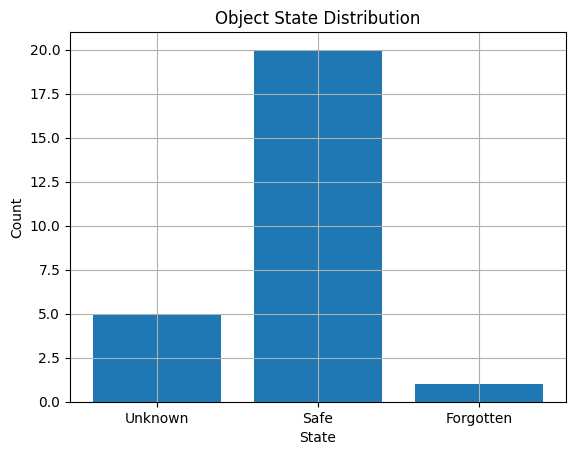

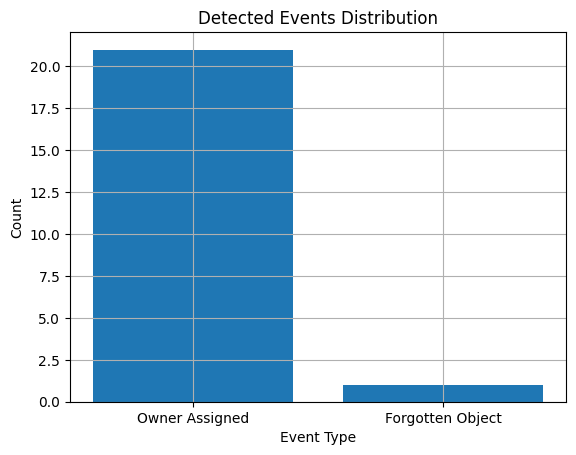


Summary Table
------------------------------
FPS: 99.73
Total Frames: 2189
Person Detections: 2189
Object Detections: 507
Unique Persons: 17
Unique Objects: 26

State Counts:
Unknown: 5
Safe: 20
Forgotten: 1

Event Counts:
Owner Assigned: 21
Forgotten Object: 1


In [26]:
visualize_results(results)

# Step 9: Evaluation log

In [27]:
import pandas as pd

# Extract data from the results dictionary
current_fps = results['fps']
current_total_frames = results['total_frames']
current_person_detections = results['person_detections']
current_object_detections = results['object_detections']
current_unique_person_ids = results['unique_person_ids']
current_unique_object_ids = results['unique_object_ids']

log_data = {
    "FPS": [current_fps],
    "Total Frames": [current_total_frames],
    "Person Detections": [current_person_detections],
    "Object Detections": [current_object_detections],
    "Unique Persons": [current_unique_person_ids],
    "Unique Objects": [current_unique_object_ids]
}

df = pd.DataFrame(log_data)

df.to_csv("evaluation_log.csv", index=False)

print("Evaluation log saved successfully. You can find it in the files sidebar.")

display(df)

Evaluation log saved successfully. You can find it in the files sidebar.


,FPS,Total Frames,Person Detections,Object Detections,Unique Persons,Unique Objects
0,99.731681,2189,2189,507,17,26
